In [80]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [81]:
train = pd.read_csv("data/ag_train.csv")

test = pd.read_csv("data/ag_test.csv")

train.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [82]:
train.shape

(120000, 3)

In [83]:
train = train.sample(10000, random_state=42).reset_index(drop=True)

In [84]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [85]:
train["text"] = (
    train["Title"] + " " + train["Description"]
)

train["text"] = train["text"].apply(clean_text)
train = train.drop_duplicates(subset=["text"]).reset_index(drop=True)

In [86]:
train[["Title", "Description", "text"]].head()

,Title,Description,text
0,"BBC set for major shake-up, claims newspaper","London - The British Broadcasting Corporation,...",bbc set for major shakeup claims newspaper lon...
1,Marsh averts cash crunch,Embattled insurance broker #39;s banks agree t...,marsh averts cash crunch embattled insurance b...
2,"Jeter, Yankees Look to Take Control (AP)",AP - Derek Jeter turned a season that started ...,jeter yankees look to take control ap ap derek...
3,Flying the Sun to Safety,When the Genesis capsule comes back to Earth w...,flying the sun to safety when the genesis caps...
4,Stocks Seen Flat as Nortel and Oil Weigh,NEW YORK (Reuters) - U.S. stocks were set to ...,stocks seen flat as nortel and oil weigh new y...


In [87]:
test["text"] = (
    test["Title"] + " " + test["Description"]
)

test["text"] = test["text"].apply(clean_text)
test = test.drop_duplicates(subset=["text"]).reset_index(drop=True)

In [88]:
test[["Title", "Description", "text"]].head()

,Title,Description,text
0,Fears for T N pension after talks,Unions representing workers at Turner Newall...,fears for t n pension after talks unions repre...
1,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",the race is on second private team sets launch...
2,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,ky company wins grant to study peptides ap ap ...
3,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,prediction unit helps forecast wildfires ap ap...
4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,calif aims to limit farmrelated smog ap ap sou...


In [89]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [90]:
embeddings = model.encode(
    train["text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [91]:
embeddings.shape

(9997, 384)

In [92]:
def semantic_search(query, model, embeddings, documents, top_k=5):

    query_embedding = model.encode([query])

    similarities = cosine_similarity(
        query_embedding,
        embeddings
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    print("Query:", query)
    print()

    for i, idx in enumerate(top_indices,1):

        print(f"Result {i}")
        print(documents[idx])
        print("-"*80)

In [93]:
semantic_search(
    "new technology in smartphones",
    model,
    embeddings,
    train["text"].tolist()
)

Query: new technology in smartphones

Result 1
boom times ahead for smartphones the popularity of mobiles packed with features is set to explode as they get better and cheaper say analysts
--------------------------------------------------------------------------------
Result 2
nokia gets a slice of blackberry pie finnish phone giant is the latest to make its devices compliant with research in motions wireless email service
--------------------------------------------------------------------------------
Result 3
the nokia s new smartphone launching the latest addition to a nowextensive line of smartphones nokia has unveiled the megapixelenabled better described as the serious cousin of the
--------------------------------------------------------------------------------
Result 4
nokia makes inroads into land rover companys communication system integrates cell phone functions into land rovers central infotainment display
-------------------------------------------------------------------

In [94]:
semantic_search(
    "football world cup",
    model,
    embeddings,
    train["text"].tolist()
)

Query: football world cup

Result 1
hosts kick off finals they will will play the opening match on june in munich although germany coach juergen klinsmann had wanted to leave that honour to another team preferably defending champions brazil provided they qualify
--------------------------------------------------------------------------------
Result 2
england wins world cup with finalround seville spain sports network paul casey and luke donald of england fired an eightunder in the alternateshot format sunday to win the world golf championships world cup
--------------------------------------------------------------------------------
Result 3
soccer big names through to uefa cup group stage london reuters most of the big names advanced safely to the inaugural group stage of the uefa cup after a frantic nights action thursday though parma real zaragoza and particularly rangers cut it fine
--------------------------------------------------------------------------------
Result 4
clash over

In [105]:
K = [2, 3, 4, 5, 6, 7, 8, 9, 10]

inertia = []

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(embeddings)

    inertia.append(kmeans.inertia_)

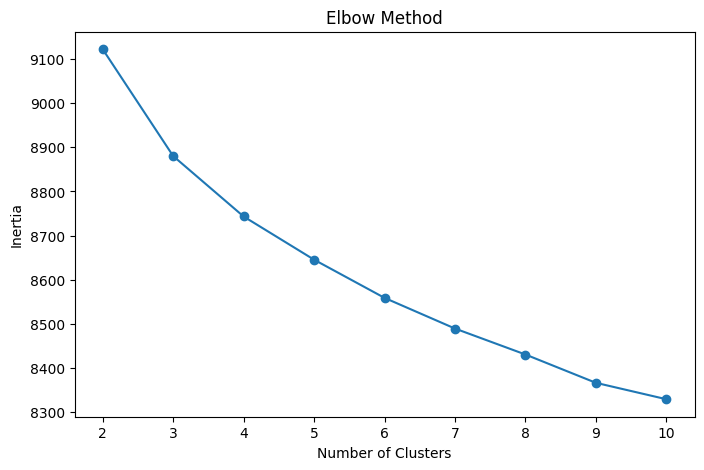

In [106]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [107]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

labels = kmeans.fit_predict(embeddings)

In [108]:
train["Cluster"] = labels
train["Cluster"].value_counts()

Cluster
0    2545
3    2478
4    1999
2    1750
1    1225
Name: count, dtype: int64

In [109]:
train.head()

,Class Index,Title,Description,text,Cluster
0,3,"BBC set for major shake-up, claims newspaper","London - The British Broadcasting Corporation,...",bbc set for major shakeup claims newspaper lon...,1
1,3,Marsh averts cash crunch,Embattled insurance broker #39;s banks agree t...,marsh averts cash crunch embattled insurance b...,0
2,2,"Jeter, Yankees Look to Take Control (AP)",AP - Derek Jeter turned a season that started ...,jeter yankees look to take control ap ap derek...,3
3,4,Flying the Sun to Safety,When the Genesis capsule comes back to Earth w...,flying the sun to safety when the genesis caps...,0
4,3,Stocks Seen Flat as Nortel and Oil Weigh,NEW YORK (Reuters) - U.S. stocks were set to ...,stocks seen flat as nortel and oil weigh new y...,1


In [110]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(embeddings)

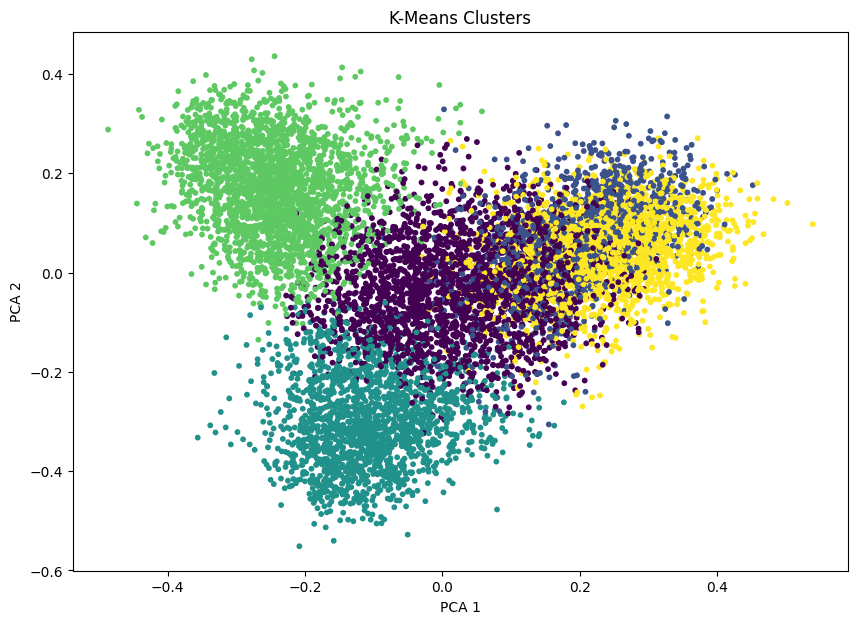

In [111]:
plt.figure(figsize=(10,7))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=labels,
    cmap="viridis",
    s=10
)

plt.title("K-Means Clusters")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

In [112]:
silhouette = silhouette_score(
    embeddings,
    labels
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.03438068926334381


In [103]:
db = davies_bouldin_score(
    embeddings,
    labels
)

print("Davies-Bouldin Index:", db)

Davies-Bouldin Index: 5.246883898007104


In [104]:
print("Number of Documents :", len(train))

print("Embedding Shape :", embeddings.shape)

print("Number of Clusters :", len(np.unique(labels)))

print("Silhouette Score :", silhouette)

print("Davies-Bouldin Index :", db)


Number of Documents : 9997
Embedding Shape : (9997, 384)
Number of Clusters : 5
Silhouette Score : 0.03438068926334381
Davies-Bouldin Index : 5.246883898007104
